<a href="https://colab.research.google.com/github/pavankhedekar/Datasets_-Repo/blob/main/TASK_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving auto-mpg.csv to auto-mpg.csv


In [3]:
filepath = '/content/auto-mpg.csv'
df = pd.read_csv(filepath)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [ ]:
df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


In [ ]:
print(df.isnull().sum())

missing_percent = (df.isnull().sum()/len(df))*100
print(missing_percent)

df = df.fillna(method='ffill')

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("After Removing:", df.shape)


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64
mpg             0.0
cylinders       0.0
displacement    0.0
horsepower      0.0
weight          0.0
acceleration    0.0
model year      0.0
origin          0.0
car name        0.0
dtype: float64
Duplicate Rows: 0
After Removing: (398, 9)


/tmp/ipykernel_674/913584371.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
print(df.describe())

print("Minimum:", df["mpg"].min())
print("Maximum:", df["mpg"].max())
print("Mean:", df["mpg"].mean())
print("Median:", df["mpg"].median())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.469388  2970.424623   
std      7.815984    1.701004    104.269838   38.199187   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   95.000000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model year      origin  
count    398.000000  398.000000  398.000000  
mean      15.568090   76.010050    1.572864  
std        2.757689    3.697627    0.802055  
min        8.000000   70.000000    1.000000  
25%       13.825000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%       17.175000   79.0000

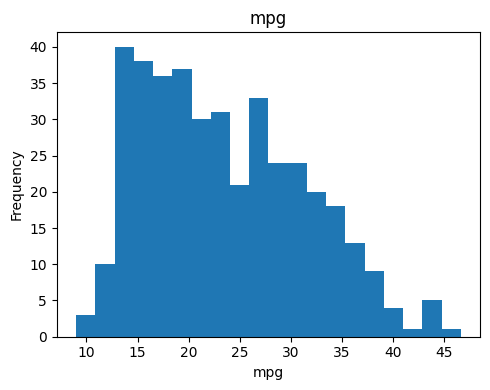

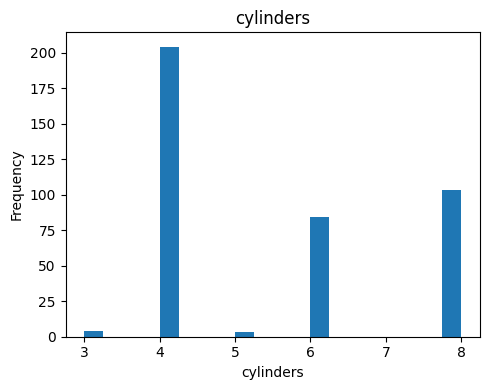

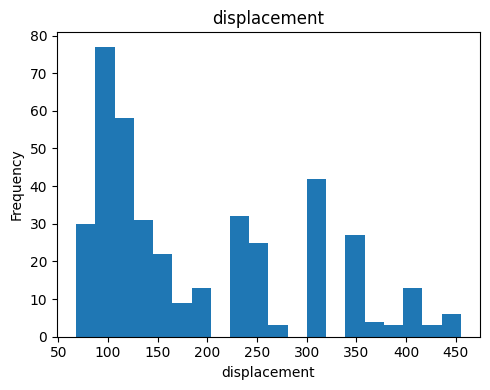

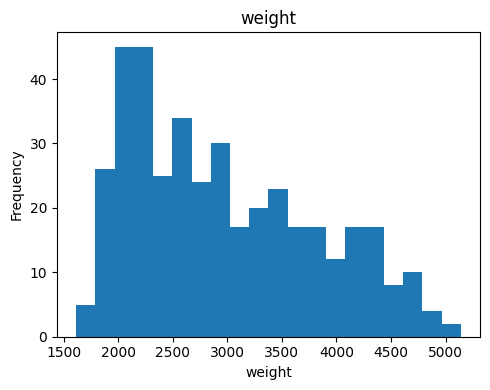

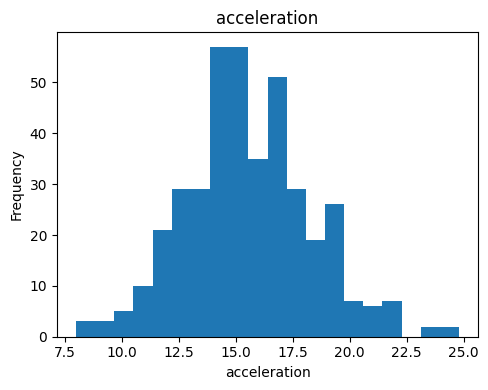

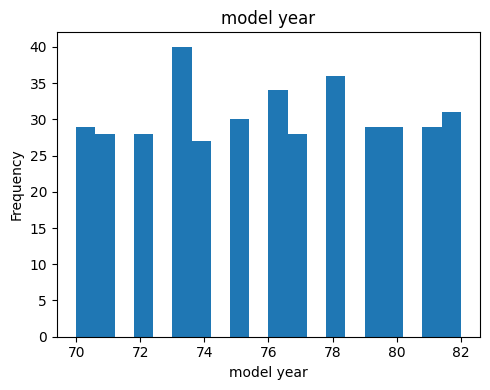

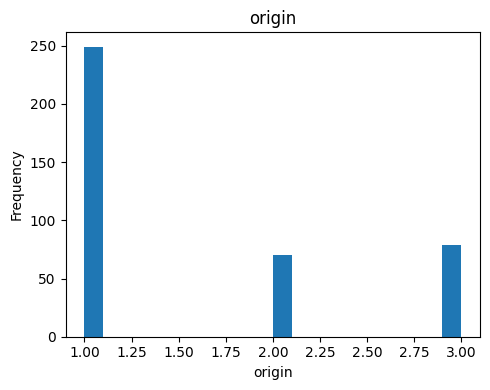

In [31]:
num_cols = df.select_dtypes('number').columns

# Histogram
for col in (num_cols):
  plt.figure(figsize=(5,4))
  plt.hist(df[col], bins=20)
  plt.title(col)
  plt.xlabel(col)
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.show()

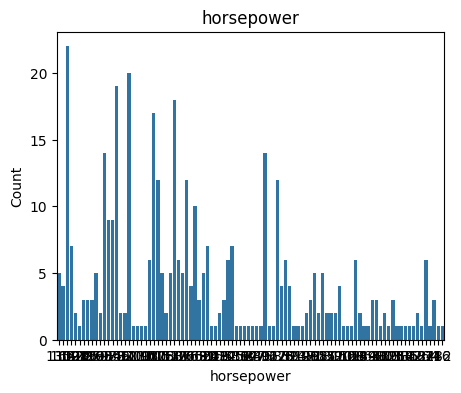

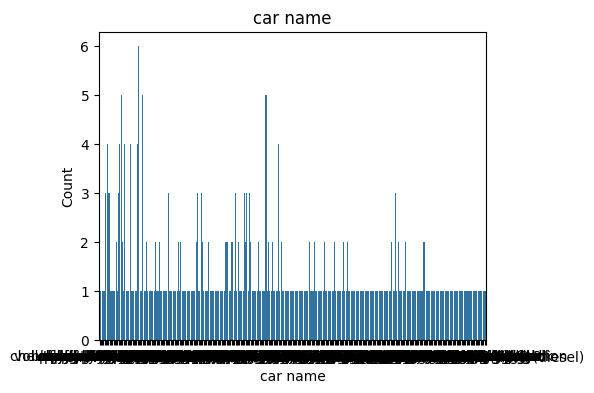

In [37]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.ylabel("Count")
    plt.show()



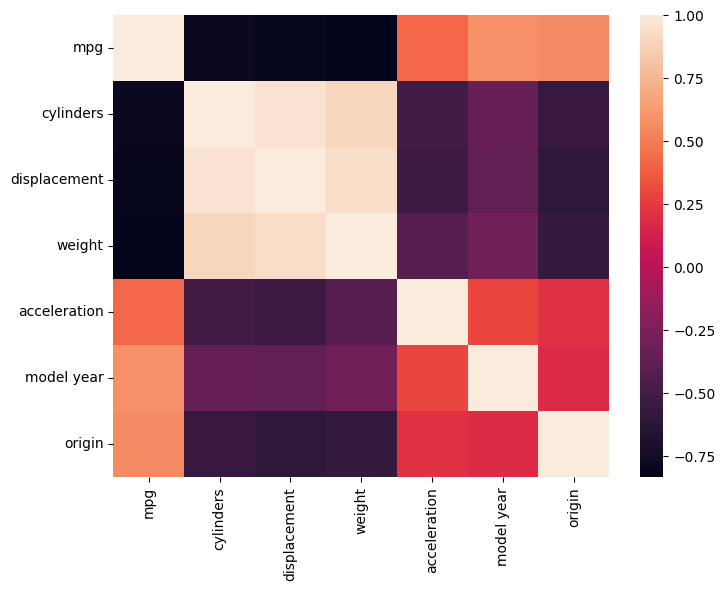

In [41]:
plt.figure(figsize=(8,6))

corr = df[num_cols].corr()
sns.heatmap(corr)
plt.show()

In [45]:
X = df.drop('mpg', axis=1)

y = df["mpg"]

print(X.head())
print(y.head())

   cylinders  displacement horsepower  weight  acceleration  model year  \
0          8         307.0        130    3504          12.0          70   
1          8         350.0        165    3693          11.5          70   
2          8         318.0        150    3436          11.0          70   
3          8         304.0        150    3433          12.0          70   
4          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64


In [49]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())

    mpg  cylinders  displacement  weight  acceleration  model year  origin  \
0  18.0          8         307.0    3504          12.0          70       1   
1  15.0          8         350.0    3693          11.5          70       1   
2  18.0          8         318.0    3436          11.0          70       1   
3  16.0          8         304.0    3433          12.0          70       1   
4  17.0          8         302.0    3449          10.5          70       1   

   horsepower_102  horsepower_103  horsepower_105  ...  \
0           False           False           False  ...   
1           False           False           False  ...   
2           False           False           False  ...   
3           False           False           False  ...   
4           False           False           False  ...   

   car name_volvo 145e (sw)  car name_volvo 244dl  car name_volvo 245  \
0                     False                 False               False   
1                     False         

In [56]:
print(df[["origin","car name"]].head())

df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.head())



   origin                   car name
0       1  chevrolet chevelle malibu
1       1          buick skylark 320
2       1         plymouth satellite
3       1              amc rebel sst
4       1                ford torino
    mpg  cylinders  displacement  weight  acceleration  model year  origin  \
0  18.0          8         307.0    3504          12.0          70       1   
1  15.0          8         350.0    3693          11.5          70       1   
2  18.0          8         318.0    3436          11.0          70       1   
3  16.0          8         304.0    3433          12.0          70       1   
4  17.0          8         302.0    3449          10.5          70       1   

   horsepower_102  horsepower_103  horsepower_105  ...  \
0           False           False           False  ...   
1           False           False           False  ...   
2           False           False           False  ...   
3           False           False           False  ...   
4           False  

In [60]:


# Select only numerical features from the encoded dataset
numeric_features = df_encoded.select_dtypes(include=[np.number]).columns

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numeric features
df_scaled = scaler.fit_transform(df_encoded[numeric_features])

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=numeric_features)

# Show the first 5 rows
print(df_scaled.head())

        mpg  cylinders  displacement    weight  acceleration  model year  \
0 -0.706439   1.498191      1.090604  0.630870     -1.295498   -1.627426   
1 -1.090751   1.498191      1.503514  0.854333     -1.477038   -1.627426   
2 -0.706439   1.498191      1.196232  0.550470     -1.658577   -1.627426   
3 -0.962647   1.498191      1.061796  0.546923     -1.295498   -1.627426   
4 -0.834543   1.498191      1.042591  0.565841     -1.840117   -1.627426   

     origin  
0 -0.715145  
1 -0.715145  
2 -0.715145  
3 -0.715145  
4 -0.715145  
